# Retail Sales Analysis Project

This notebook analyzes a retail sales dataset to answer business questions such as:

- Top products by revenue
- Monthly sales trends
- Best performing regions
- Total revenue and average order value
- Final business recommendations


## 1. Import Required Libraries

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.pagesizes import letter
from reportlab.lib.units import inch

## 2. Create Retail Sales Dataset

In [6]:
np.random.seed(42)

dates = pd.date_range(start='2025-01-01', end='2025-12-31', freq='D')
products = ['Laptop', 'Phone', 'Headphones', 'Keyboard', 'Monitor', 'Tablet']
regions = ['North', 'South', 'East', 'West']

data = []

for _ in range(1200):
    date = np.random.choice(dates)
    product = np.random.choice(products)
    region = np.random.choice(regions)
    quantity = np.random.randint(1, 6)

    price = {
        'Laptop': 1200,
        'Phone': 800,
        'Headphones': 150,
        'Keyboard': 90,
        'Monitor': 300,
        'Tablet': 500
    }[product]

    revenue = quantity * price
    order_id = np.random.randint(10000, 99999)

    data.append([date, product, region, quantity, revenue, order_id])

df = pd.DataFrame(data, columns=['Date', 'Product', 'Region', 'Quantity', 'Revenue', 'OrderID'])

df.head()

,Date,Product,Region,Quantity,Revenue,OrderID
0,2025-04-13,Keyboard,North,3,270,86820
1,2025-04-13,Phone,East,3,2400,97498
2,2025-03-29,Monitor,West,3,900,77221
3,2025-11-05,Phone,West,4,3200,74925
4,2025-10-21,Phone,West,4,3200,93104


## 3. Save Dataset as CSV

In [7]:
df.to_csv('retail_sales_dataset.csv', index=False)
print('Dataset saved as retail_sales_dataset.csv')

Dataset saved as retail_sales_dataset.csv


## 4. Basic Dataset Information

In [8]:
print('Dataset Shape:', df.shape)
print('\nMissing Values:')
print(df.isnull().sum())

print('\nDataset Info:')
df.info()

Dataset Shape: (1200, 6)

Missing Values:
Date        0
Product     0
Region      0
Quantity    0
Revenue     0
OrderID     0
dtype: int64

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      1200 non-null   datetime64[ns]
 1   Product   1200 non-null   object        
 2   Region    1200 non-null   object        
 3   Quantity  1200 non-null   int64         
 4   Revenue   1200 non-null   int64         
 5   OrderID   1200 non-null   int64         
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 56.4+ KB


## 5. KPI Calculation

In [9]:
total_revenue = df['Revenue'].sum()
avg_order_value = df.groupby('OrderID')['Revenue'].sum().mean()
top_region = df.groupby('Region')['Revenue'].sum().idxmax()
top_product = df.groupby('Product')['Revenue'].sum().idxmax()

print('===== Key Performance Indicators =====')
print(f'Total Revenue: ${total_revenue:,.2f}')
print(f'Average Order Value: ${avg_order_value:,.2f}')
print(f'Top Region: {top_region}')
print(f'Best Selling Product: {top_product}')

===== Key Performance Indicators =====
Total Revenue: $1,797,210.00
Average Order Value: $1,517.91
Top Region: North
Best Selling Product: Laptop


## 6. Monthly Revenue Trend

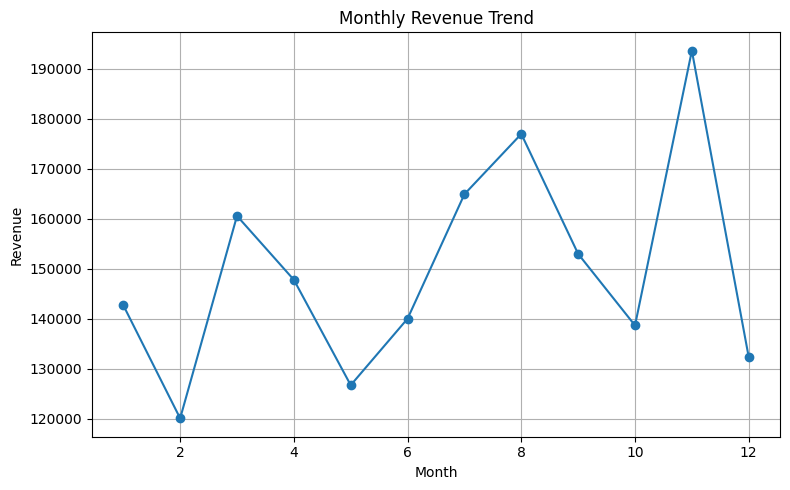

In [10]:
monthly_sales = df.groupby(df['Date'].dt.month)['Revenue'].sum()

plt.figure(figsize=(8, 5))
monthly_sales.plot(marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)
plt.tight_layout()
plt.savefig('monthly_trend.png')
plt.show()

## 7. Top Products by Revenue

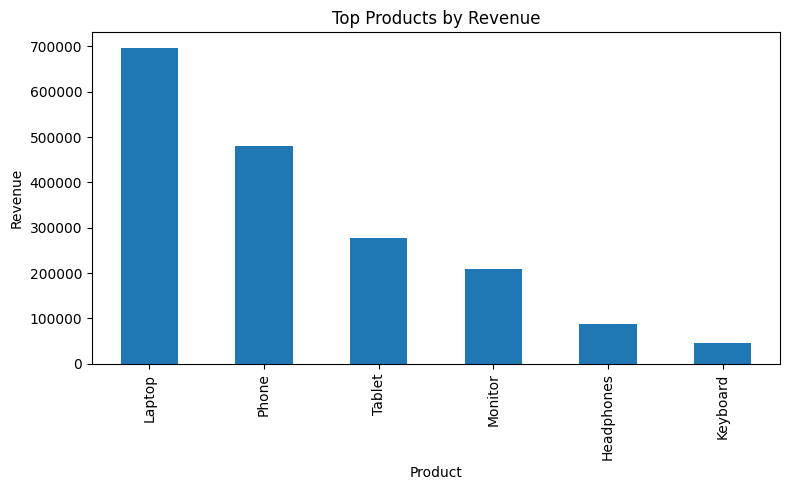

Product
Laptop        696000
Phone         480800
Tablet        277000
Monitor       209100
Headphones     88050
Keyboard       46260
Name: Revenue, dtype: int64

In [11]:
product_sales = df.groupby('Product')['Revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
product_sales.plot(kind='bar')
plt.title('Top Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.tight_layout()
plt.savefig('top_products.png')
plt.show()

product_sales

## 8. Revenue by Region

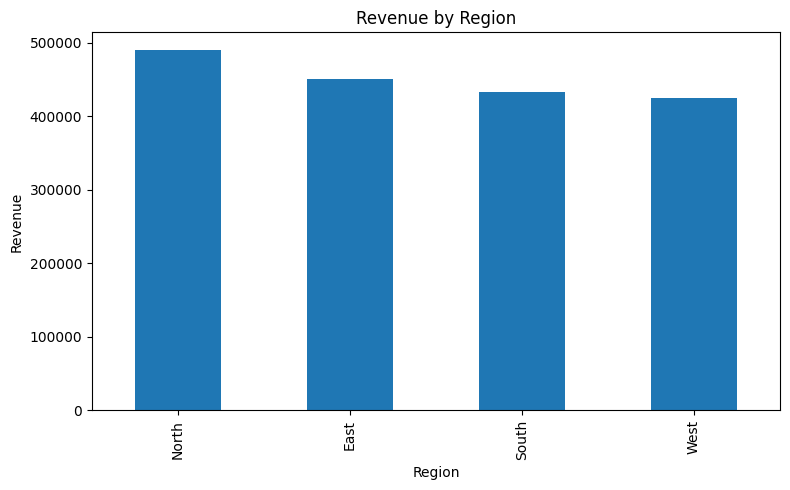

Region
North    489360
East     450740
South    432630
West     424480
Name: Revenue, dtype: int64

In [12]:
region_sales = df.groupby('Region')['Revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
region_sales.plot(kind='bar')
plt.title('Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Revenue')
plt.tight_layout()
plt.savefig('regions.png')
plt.show()

region_sales

## 9. Business Insights

In [13]:
print('===== Business Insights =====')
print(f'1. Total revenue generated is ${total_revenue:,.2f}.')
print(f'2. Average order value is ${avg_order_value:,.2f}.')
print(f'3. The best performing region is {top_region}.')
print(f'4. The highest revenue generating product is {top_product}.')
print('5. Monthly revenue trend helps identify seasonal demand patterns.')

===== Business Insights =====
1. Total revenue generated is $1,797,210.00.
2. Average order value is $1,517.91.
3. The best performing region is North.
4. The highest revenue generating product is Laptop.
5. Monthly revenue trend helps identify seasonal demand patterns.


## 10. Recommendations

In [14]:
recommendations = [
    'Increase inventory for top-performing products during high-demand months.',
    'Run marketing campaigns in weaker regions to improve regional sales.',
    'Create product bundle offers to increase average order value.',
    'Focus more on products that generate higher revenue.',
    'Use seasonal discounts to improve sales during low-performing months.'
]

for i, rec in enumerate(recommendations, start=1):
    print(f'{i}. {rec}')

1. Increase inventory for top-performing products during high-demand months.
2. Run marketing campaigns in weaker regions to improve regional sales.
3. Create product bundle offers to increase average order value.
4. Focus more on products that generate higher revenue.
5. Use seasonal discounts to improve sales during low-performing months.


## 11. Export One-Page PDF Summary

In [19]:
pdf_path = 'sales_analysis_summary.pdf'

doc = SimpleDocTemplate(pdf_path, pagesize=letter)
styles = getSampleStyleSheet()
elements = []

title = Paragraph('<b>Retail Sales Analysis Report</b>', styles['Title'])
elements.append(title)
elements.append(Spacer(1, 12))

summary_text = f'''
<b>Key Performance Indicators</b><br/><br/>

- Total Revenue: ${total_revenue:,.2f}<br/>
- Average Order Value: ${avg_order_value:,.2f}<br/>
- Top Region: {top_region}<br/>
- Best Selling Product: {top_product}<br/><br/>

<b>Business Insights</b><br/><br/>

- The business generated strong yearly revenue from multiple products.<br/>
- {top_product} was the highest revenue generating product.<br/>
- {top_region} was the strongest performing region.<br/>
- Monthly revenue trends show useful seasonal patterns.<br/><br/>

<b>Recommendations</b><br/><br/>

- Increase stock for best-selling products.<br/>
- Run targeted campaigns in weaker regions.<br/>
- Introduce product bundles to improve average order value.<br/>
- Use seasonal promotions during low-sales months.<br/>
'''

elements.append(Paragraph(summary_text, styles['BodyText']))
elements.append(Spacer(1, 12))

for img in ['monthly_trend.png', 'top_products.png', 'regions.png']:
    elements.append(Image(img, width=5.8 * inch, height=3 * inch))
    elements.append(Spacer(1, 10))

doc.build(elements)

print('PDF report generated successfully:', pdf_path)

PDF report generated successfully: sales_analysis_summary.pdf


## Project Completed

Generated output files:

- `retail_sales_dataset.csv`
- `monthly_trend.png`
- `top_products.png`
- `regions.png`
- `sales_analysis_summary.pdf`
